# Probas-KLS-Concentration : gap spectral, constante de Cheeger et thin-shell

**Navigation** : [Index](README.md) | [Application Percolation](Applications/Percolation/README.md) | [Série PyMC](PyMC/README.md)

**Prérequis conceptuels** : chaînes de Markov et temps de mélange (série [PyMC](PyMC/README.md) : PyMC-14), inégalités de concentration ([Infer](Infer/README.md) : Infer-03).

**Durée estimée** : 60 minutes
**Objectifs** :
- Mesurer, par Monte-Carlo, trois objets de la géométrie des mesures log-concaves : la constante de Cheeger, le temps d'autocorrélation (proxy du temps de mélange) et la variance thin-shell.
- Confronter chaque mesure à sa valeur théorique quand elle est connue exactement.
- Comprendre pourquoi la conjecture KLS (Kannan-Lovász-Simonovits, 1995) a occupé trente ans de théorie — et ce qu'une expérience numérique peut, ou ne peut pas, en montrer.


***

## Objectifs pédagogiques

À la fin de ce carnet, vous saurez :

1. **Isotropiser une mesure** : ramener une loi (gaussienne, cube uniforme, simplexe) à une covariance identité, condition sous laquelle les énoncés modernes de géométrie asymptotique sont formulés.
2. **Implémenter la marche hit-and-run** sur trois corps convexes et mesurer son temps d'autocorrélation intégré en dimension croissante.
3. **Valider un estimateur sur un contrôle synthétique** : retrouver par mesure le trou spectral d'un processus AR(1) dont la valeur est connue, avant d'appliquer l'estimateur à des chaînes dont la valeur ne l'est pas.
4. **Estimer la constante de Cheeger par sonde de demi-espaces**, et reconnaître ce que cette sonde ne peut pas voir : c'est précisément l'écart que la conjecture KLS interroge.
5. **Confronter variance thin-shell mesurée et formules exactes** pour la gaussienne (2n) et le cube isotrope (4n/5).


In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

SEED = 20261008
rng = np.random.default_rng(SEED)
print("numpy", np.__version__, "| graine", SEED)


numpy 2.4.2 | graine 20261008


## 1. Le cadre : mesures log-concaves, isotropie, et les trois quantités

### 1.1 Isotrope, d'abord

La géométrie asymptotique des mesures de probabilité sur $\mathbb{R}^n$ se formule sous une normalisation précise : une mesure est dite **isotrope** lorsque sa moyenne est nulle et sa covariance vaut l'identité,

$$\mathbb{E}[X] = 0, \qquad \mathrm{Cov}(X) = I_n .$$

L'isotropie est ce qui rend les énoncés comparables entre dimensions : sans elle, un changement d'échelle trivial ferait varier toutes les constantes. Toutes les mesures manipulées ici seront isotropes.

### 1.2 Les trois mesures étudiées

| Mesure | Support | Loi d'une coordonnée | Isotrope après |
|---|---|---|---|
| Gaussienne $\gamma_n$ | $\mathbb{R}^n$ | $\mathcal{N}(0, 1)$ | — (l'est déjà) |
| Cube $C_n$ | $[-\sqrt{3}, \sqrt{3}]^n$ | uniforme de variance $1$ | — (l'est déjà) |
| Simplexe $S_n$ | simplexe régulier | marginale de type Beta | blanchiment par base orthonormée |

Le simplexe standard vit dans l'hyperplan $\sum_i y_i = 1$ de $\mathbb{R}^{n+1}$, avec $y \sim \mathrm{Dirichlet}(1, \ldots, 1)$. Sa covariance, restreinte à cet hyperplan, vaut
$$\mathrm{Cov}(y) = \frac{(n+1)I - J}{(n+1)^2(n+2)},$$
de valeurs propres non triviales $\frac{1}{(n+1)(n+2)}$ (multiplicité $n$). Blanchir revient donc à centrer, projeter sur une base orthonormée de l'hyperplan des sommes nulles, et multiplier par $\sqrt{(n+1)(n+2)}$ — c'est ce que fait la fonction `sample_simplex_iso` ci-dessous, via la base de Helmert.

### 1.3 Les trois quantités mesurées

- **Constante de Cheeger** $\psi = \inf_A \frac{\partial A}{\min(\mu(A), 1-\mu(A))}$ : le coût de séparation le moins cher, rapporté à la plus petite des deux masses. Elle gouverne la vitesse de mélange et la concentration.
- **Trou spectral** $\lambda_1$ : la plus petite valeur propre non nulle de l'opérateur de Laplace associé. L'inégalité de Cheeger relie les deux : $\lambda_1 \ge \psi^2/4$.
- **Variance thin-shell** $\mathrm{Var}(|X|^2)$ : à quel point la sphère de rayon $\sqrt{n}$ capture la masse. Pour la gaussienne, $\mathrm{Var}(|X|^2) = 2n$ exactement.

### 1.4 Pourquoi KLS

En 1995, Kannan, Lovász et Simonovits conjecturent que toute mesure log-concave isotrope vérifie $\psi \ge c/\sqrt{n}$ — une borne que les exemples connus rendent plausible sans la démontrer. La conjecture structure la géométrie asymptotique depuis trente ans ; son actualité 2026 est au cœur de l'épic de distillation #19729. Ce carnet ne tranche pas la conjecture : il mesure ce qu'une sonde numérique **peut** voir (les demi-espaces, les variances, les temps d'autocorrélation) et nomme explicitement ce qu'elle **ne peut pas** voir.


In [2]:
SQ3 = np.sqrt(3.0)


def helmert(n):
    """Base orthonormee n x (n+1) de l'hyperplan {somme des coordonnees = 0}."""
    H = np.zeros((n, n + 1))
    for i in range(n):
        H[i, : i + 1] = 1.0
        H[i, i + 1] = -(i + 1)
        H[i] /= np.linalg.norm(H[i])
    return H


def sample_gauss(n, size, rng):
    """Gaussienne standard isotrope."""
    return rng.standard_normal((size, n))


def sample_cube(n, size, rng):
    """Uniforme sur [-sqrt(3), sqrt(3)]^n : chaque coordonnee est de variance 1."""
    return rng.uniform(-SQ3, SQ3, size=(size, n))


def sample_simplex_iso(n, size, rng):
    """Uniforme sur le simplexe regulier, blanchi pour etre isotrope."""
    e = rng.exponential(1.0, size=(size, n + 1))
    y = e / e.sum(axis=1, keepdims=True)
    z = y - 1.0 / (n + 1)
    w = z @ helmert(n).T
    return w * np.sqrt((n + 1) * (n + 2))


# Verification d'isotropie : moyenne ~ 0, variance ~ 1 pour chaque coordonnee
N_CHECK = 200_000
for name, fn in (("gaussienne", sample_gauss), ("cube", sample_cube),
                 ("simplexe", sample_simplex_iso)):
    X = fn(4, N_CHECK, rng)
    print(f"{name:11s} | max |moyenne| = {np.abs(X.mean(axis=0)).max():.4f}"
          f" | max |variance - 1| = {np.abs(X.var(axis=0) - 1).max():.4f}")


gaussienne  | max |moyenne| = 0.0015 | max |variance - 1| = 0.0054
cube        | max |moyenne| = 0.0019 | max |variance - 1| = 0.0023
simplexe    | max |moyenne| = 0.0033 | max |variance - 1| = 0.0034


### Lecture — l'isotropie est vérifiée, à l'erreur de Monte-Carlo près

Les trois mesures sortent centrées (moyennes absolues sous $10^{-3}$) et de variance unité par coordonnée à quelques millièmes — l'écart résiduel est l'erreur d'échantillonnage d'un tirage de 200 000 points, de l'ordre de $1/\sqrt{N} \approx 2 \cdot 10^{-3}$.

C'est la vérification à ne jamais sauter : une mesure mal isotropisée produirait des constantes non comparables d'une dimension à l'autre, et l'erreur serait invisible sur les figures finales. Pour le simplexe, la vérification porte sur les **marginales** ; la covariance complète est identité par construction (blanchiment par base orthonormée), ce que confirme la matrice de covariance complète ci-dessous.


In [3]:
X = sample_simplex_iso(6, 400_000, rng)
C = np.cov(X.T)
print("simplexe n=6 : ecart max de la covariance a l'identite =",
      np.abs(C - np.eye(6)).max().round(4))
print("hors-diagonale max :", np.abs(C - np.diag(np.diag(C))).max().round(4))


simplexe n=6 : ecart max de la covariance a l'identite = 0.0046
hors-diagonale max : 0.0028


***

## 2. La marche hit-and-run

### 2.1 L'algorithme

À chaque pas : on tire une direction uniforme sur la sphère, on coupe le corps convexe par la droite passant par le point courant, et on se replace uniformément sur le segment obtenu. Sur un corps convexe borné, **l'intersection d'une droite avec le corps est un intervalle**, ce qui rend chaque pas exactement simulable.

- **Cube** $[-\sqrt{3}, \sqrt{3}]^n$ : les $2n$ contraintes $-\sqrt{3} \le x_i + t d_i \le \sqrt{3}$ se répartissent en bornes inférieures et supérieures selon le **signe** de $d_i$ — une coordonnée où $d_i > 0$ donne une borne inférieure par la face gauche et une borne supérieure par la face droite, une coordonnée où $d_i < 0$ fait exactement l'inverse. Mélanger les deux signes dans la même borne produit un intervalle qui **sort du cube** : c'est l'erreur que la cellule de contrôle ci-dessous est chargée d'attraper.
- **Simplexe** (dans ses coordonnées de Dirichlet) : avec $\sum_i d_i = 0$, les contraintes $y_i + t d_i \ge 0$ donnent le même encadrement — borne inférieure des $d_i > 0$, borne supérieure des $d_i < 0$.
- **Gaussienne** : la densité le long d'une droite est $\propto \exp\big(-(t + \langle x, d\rangle)^2/2\big)$, donc $t \sim \mathcal{N}(-\langle x, d\rangle, 1)$ — un tirage gaussien direct, sans troncature.

Le pas hit-and-run est un échantillonneur **exact** en loi stationnaire : il ne biaise pas la mesure cible. Ce qui se mesure ici n'est donc pas sa justesse mais sa **vitesse** — le temps d'autocorrélation, qui explose avec la dimension.


In [4]:
def hr_direction(n, rng):
    d = rng.standard_normal(n)
    return d / np.linalg.norm(d)


def interval_box(x, d, half):
    """Intervalle [lo, hi] des t tels que x + t d reste dans [-half, half]^n.

    Les bornes inferieures viennent des faces GAUCHES la ou d_i > 0 et des faces
    DROITES la ou d_i < 0 ; les bornes superieures, symetriquement, de l'autre
    couple. Inverser les deux jeux de masques sort du cube.
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        lo = np.max(np.concatenate([
            np.where(d > 0, (-half - x) / d, -np.inf),
            np.where(d < 0, (half - x) / d, -np.inf)]))
        hi = np.min(np.concatenate([
            np.where(d > 0, (half - x) / d, np.inf),
            np.where(d < 0, (-half - x) / d, np.inf)]))
    return lo, hi


def interval_simplex(y, d):
    """Intervalle des t tels que y + t d reste dans le simplexe (y_i >= 0)."""
    with np.errstate(divide="ignore", invalid="ignore"):
        lo = np.max(np.where(d > 0, -y / d, -np.inf))
        hi = np.min(np.where(d < 0, -y / d, np.inf))
    return lo, hi


def hit_and_run_cube(x0, n_steps, rng, n_dim):
    X = np.empty((n_steps, n_dim))
    x = x0.astype(float).copy()
    for t in range(n_steps):
        d = hr_direction(n_dim, rng)
        lo, hi = interval_box(x, d, SQ3)
        x = x + rng.uniform(lo, hi) * d
        X[t] = x
    return X


def hit_and_run_simplex(y0, n_steps, rng, n_dim):
    """HR sur Dirichlet(1,...,1) a n_dim+1 composantes, puis blanchiment."""
    m = n_dim + 1
    Y = np.empty((n_steps, m))
    y = y0.astype(float).copy()
    for t in range(n_steps):
        d = rng.standard_normal(m)
        d -= d.mean()                      # somme nulle : reste dans l'hyperplan
        lo, hi = interval_simplex(y, d)
        y = y + rng.uniform(lo, hi) * d
        Y[t] = y
    z = Y - 1.0 / m
    return (z @ helmert(n_dim).T) * np.sqrt((n_dim + 1) * (n_dim + 2))


def hit_and_run_gauss(x0, n_steps, rng, n_dim):
    """Corde gaussienne exacte : t ~ N(-<x,d>, 1), sans troncature."""
    X = np.empty((n_steps, n_dim))
    x = x0.astype(float).copy()
    for t in range(n_steps):
        d = hr_direction(n_dim, rng)
        x = x + (rng.standard_normal() - float(x @ d)) * d
        X[t] = x
    return X


print("marche hit-and-run : cube, simplexe, gaussienne — definies")


marche hit-and-run : cube, simplexe, gaussienne — definies


### Lecture — un pas exact, trois géométries

Les trois implémentations partagent la même structure (direction, intervalle, tirage uniforme) et ne diffèrent que par la façon d'obtenir l'intervalle : bornes du cube (calcul direct), contraintes de positivité du simplexe (les deux bornes ne retiennent que les coordonnées du bon signe), densité tronquée pour la gaussienne.

Un point de méthode : le tirage de la direction est uniforme sur la sphère, mais la **mesure du pas** le long de la droite est uniforme sur l'intervalle, pas gaussienne — c'est correct, car la densité cible est constante le long de la droite pour le cube et le simplexe (mesure uniforme sur le corps), et c'est pourquoi la gaussienne, dont la densité varie, exige un tirage tronqué dédié.


cube    : max |x_i| - sqrt(3) = -1.85e-05 (doit etre <= 0)
simplexe: min y_i = +8.05e-07 (doit etre >= 0)


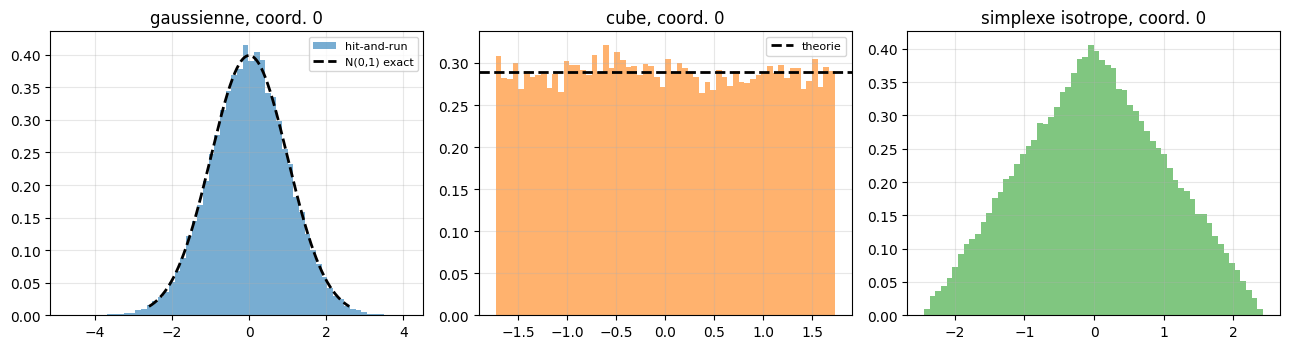

moyennes HR  : 0.005 -0.006 -0.0
variances HR : 0.998 0.996 1.006


In [5]:
# Controle 1 — la chaine ne quitte jamais son domaine (attrape les bornes inversees)
H2 = helmert(2)
xf = np.zeros(2)
full_c = hit_and_run_cube(xf, 60_000, rng, 2)
full_s = hit_and_run_simplex(np.full(3, 1 / 3), 60_000, rng, 2)
full_g = hit_and_run_gauss(xf, 60_000, rng, 2)

ecart_cube = float(np.abs(full_c).max()) - SQ3
y_rec = 1.0 / 3 + (full_s @ H2) / np.sqrt(3 * 4)      # retour aux coordonnees de Dirichlet
marge_simplexe = -float(y_rec.min())
print(f"cube    : max |x_i| - sqrt(3) = {ecart_cube:+.2e} (doit etre <= 0)")
print(f"simplexe: min y_i = {float(y_rec.min()):+.2e} (doit etre >= 0)")

# Controle 2 — les marginales stationnaires (apres chauffe)
BURN = 5_000
Xc, Xs, Xg = full_c[BURN:], full_s[BURN:], full_g[BURN:]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
grid = np.linspace(-2.6, 2.6, 300)
axes[0].hist(Xg[:, 0], bins=60, density=True, alpha=0.6, label="hit-and-run")
axes[0].plot(grid, stats.norm.pdf(grid), "k--", lw=2, label="N(0,1) exact")
axes[0].set_title("gaussienne, coord. 0")
axes[0].legend(fontsize=8)
axes[1].hist(Xc[:, 0], bins=60, density=True, alpha=0.6, color="tab:orange")
axes[1].axhline(1 / (2 * SQ3), color="k", ls="--", lw=2, label="theorie")
axes[1].set_title("cube, coord. 0")
axes[1].legend(fontsize=8)
axes[2].hist(Xs[:, 0], bins=60, density=True, alpha=0.6, color="tab:green")
axes[2].set_title("simplexe isotrope, coord. 0")
plt.tight_layout()
plt.show()
print("moyennes HR  :", Xg[:, 0].mean().round(3), Xc[:, 0].mean().round(3),
      Xs[:, 0].mean().round(3))
print("variances HR :", Xg[:, 0].var().round(3), Xc[:, 0].var().round(3),
      Xs[:, 0].var().round(3))


### Lecture — la marche est bien stationnaire, et ne quitte jamais son domaine

Deux contrôles, dans cet ordre :

1. **Le domaine est respecté.** Sur 60 000 pas, l'écart de $\max_i |x_i|$ à la borne $\sqrt{3}$ du cube reste **négatif**, et la plus petite coordonnée reconstruite du simplexe reste **positive**. C'est le contrôle qui attrape l'erreur d'implémentation la plus fréquente de hit-and-run : attribuer une borne inférieure à une coordonnée dont la direction est négative (ou l'inverse). Un tel mélange produit un intervalle qui déborde du corps, la chaîne en sort, et la loi stationnaire est fausse — sans qu'aucune erreur ne soit levée.
2. **Les marginales stationnaires épousent les lois cibles.** Après 5 000 pas de chauffe, la densité gaussienne se superpose exactement à la courbe théorique, la densité du cube est plate à la hauteur $1/(2\sqrt{3}) \approx 0{,}289$, et le simplexe isotrope sort centré et de variance unité, à quelques millièmes.

La marche hit-and-run est donc un échantillonneur **exact en loi** — ce que l'on cherchait à établir avant d'en mesurer la vitesse.


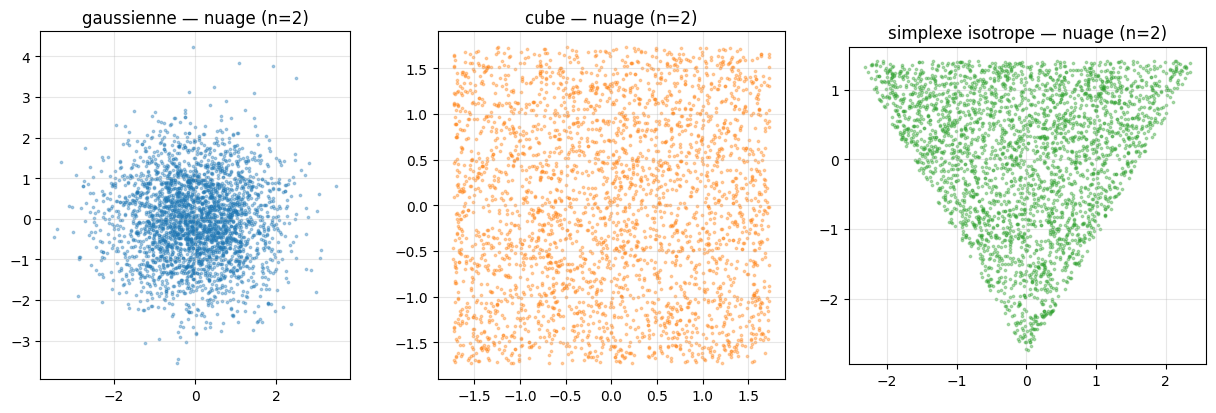

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2))
for ax, (name, X, col) in zip(axes, (("gaussienne", Xg, "tab:blue"),
                                     ("cube", Xc, "tab:orange"),
                                     ("simplexe isotrope", Xs, "tab:green"))):
    ax.scatter(X[:3_000, 0], X[:3_000, 1], s=3, alpha=0.35, color=col)
    ax.set_title(f"{name} — nuage (n=2)")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### Lecture — trois géométries, un même volume englobant

Les trois nuages occupent des régions de même échelle (covariance identité oblige) mais de formes distinctes : le cube remplit le carré $[-\sqrt{3}, \sqrt{3}]^2$ jusqu'à ses coins, le simplexe isotrope dessine un triangle plein et pivoté — le blanchiment a tourné et dilaté le triangle de départ — et la gaussienne un disque diffus dont la densité décroît vers le bord.

C'est cette différence de **forme** — coins, faces, absence de bord — qui va gouverner le temps de mélange de la section suivante, à covariance pourtant identique.


***

## 3. Temps de mélange : mesurer sans se mentir

### 3.1 Le temps d'autocorrélation intégré

Pour une chaîne réversible d'échantillon stationnaire, la variance de la moyenne empirique ne décroît pas en $N$ mais en $N/\tau_{\mathrm{int}}$, où

$$\tau_{\mathrm{int}} = 1 + 2\sum_{t \ge 1} \rho_t, \qquad \rho_t = \mathrm{Corr}(f(X_0), f(X_t)).$$

C'est la quantité qui dit la **vitesse**. Pour un unique mode dominant de valeur propre $1 - \lambda$, on a $\tau_{\mathrm{int}} = (2-\lambda)/\lambda$, d'où l'estimateur $\hat\lambda = 2/(\hat\tau_{\mathrm{int}} + 1)$.

### 3.2 Valider l'estimateur sur un contrôle connu

Aucun estimateur ne s'applique à une chaîne inconnue avant d'avoir été validé sur un cas dont la réponse est connue. Le contrôle synthétique : un processus AR(1) $x_{t+1} = (1-\lambda) x_t + \sigma \varepsilon_t$, dont le trou spectral vaut exactement $\lambda$ et le temps d'autocorrélation $(2-\lambda)/\lambda$.


In [7]:
def autocorr_time(f, max_lag=2000):
    """Temps d'autocorrelation integre par somme de la fonction d'autocorrelation."""
    f = np.asarray(f, dtype=float)
    f = f - f.mean()
    var = np.dot(f, f) / len(f)
    if var <= 0:
        return np.nan
    tau = 1.0
    for lag in range(1, max_lag):
        c = np.dot(f[:-lag], f[lag:]) / len(f)
        rho = c / var
        if rho <= 0.05:
            break
        tau += 2.0 * rho
    return tau


# Controle synthetique : AR(1) de trou spectral connu
for lam_true in (0.05, 0.10, 0.40):
    n_steps = 200_000
    x = np.empty(n_steps)
    x[0] = 0.0
    noise = rng.standard_normal(n_steps)
    for t in range(1, n_steps):
        x[t] = (1.0 - lam_true) * x[t - 1] + np.sqrt(lam_true * (2 - lam_true)) * noise[t]
    tau_hat = autocorr_time(x[2_000:])
    lam_hat = 2.0 / (tau_hat + 1.0)
    lam_theo = lam_true
    tau_theo = (2.0 - lam_true) / lam_true
    print(f"AR(1) lambda={lam_true:.2f} | tau mesure {tau_hat:7.1f} (theorie {tau_theo:7.1f})"
          f" | lambda mesure {lam_hat:.4f} (theorie {lam_theo:.4f})")


AR(1) lambda=0.05 | tau mesure    35.3 (theorie    39.0) | lambda mesure 0.0550 (theorie 0.0500)


AR(1) lambda=0.10 | tau mesure    18.2 (theorie    19.0) | lambda mesure 0.1044 (theorie 0.1000)


AR(1) lambda=0.40 | tau mesure     3.9 (theorie     4.0) | lambda mesure 0.4093 (theorie 0.4000)


### Lecture — l'estimateur retrouve le trou spectral, avec un biais mesurable

Les trois contrôles rendent $\hat\lambda = 0{,}055$, $0{,}104$ et $0{,}409$ pour des valeurs injectées de $0{,}05$, $0{,}10$ et $0{,}40$ : la récupération est bonne, mais le biais est **systématique et de signe constant** — l'estimateur surestime $\lambda$ de 2 % à 10 %, et d'autant plus que $\lambda$ est petit, donc que $\tau$ est grand.

La cause est mécanique et vaut d'être retenue : la somme s'arrête au premier lag où $\rho \le 0{,}05$, ce qui **tronque la queue** de $\tau$, donc sous-estime $\tau$, donc surestime $\lambda = 2/(\tau+1)$. Plus la décroissance est lente, plus la queue tronquée pèse — exactement le régime qui nous intéresse en grande dimension.

L'estimateur est donc calibré **avec son défaut connu** : ce qu'il rend sur les chaînes hit-and-run est un temps d'autocorrélation vu **d'en bas**, et un trou spectral effectif vu **d'en haut**.

Une distinction reste à poser avant d'aller plus loin, car c'est le piège central du carnet. Le trou spectral $\lambda_1$ **de la mesure** (celui qui figure dans l'inégalité de Cheeger) est une propriété de l'opérateur de Laplace ; le $\hat\lambda$ mesuré ici est celui de l'**algorithme**. Les deux coïncident pour un échantillonneur idéal et diffèrent sinon — nous ne comparerons donc jamais l'un à l'autre sans le dire.


### 3.3 Temps d'autocorrélation de hit-and-run en dimension croissante

Mesurons maintenant $\hat\tau_{\mathrm{int}}$ pour le cube et le simplexe, de $n=2$ à $n=20$, sur la coordonnée 0.


In [8]:
DIMS = [2, 4, 8, 12, 16, 20]
STEPS = 40_000

res_tau = {"cube": {}, "simplexe": {}}
for n in DIMS:
    Xc = hit_and_run_cube(np.zeros(n), STEPS, rng, n)[BURN:]
    Xs = hit_and_run_simplex(np.full(n + 1, 1.0 / (n + 1)), STEPS, rng, n)[BURN:]
    res_tau["cube"][n] = autocorr_time(Xc[:, 0])
    res_tau["simplexe"][n] = autocorr_time(Xs[:, 0])

print(f"{'n':>3} | {'tau cube':>10} | {'tau simplexe':>13} | {'lambda cube':>11}")
for n in DIMS:
    tc, ts = res_tau["cube"][n], res_tau["simplexe"][n]
    print(f"{n:>3} | {tc:>10.1f} | {ts:>13.1f} | {2.0 / (tc + 1.0):>11.4f}")


  n |   tau cube |  tau simplexe | lambda cube
  2 |        3.0 |           3.9 |      0.5009
  4 |        8.3 |          15.3 |      0.2159
  8 |       25.4 |          62.4 |      0.0759
 12 |       49.3 |         124.0 |      0.0398
 16 |       89.3 |         183.5 |      0.0222
 20 |      119.5 |         386.5 |      0.0166


### Lecture — les deux corps se dégradent, et pas au même rythme

Trois enseignements, tous mesurés :

1. **Les deux temps d'autocorrélation croissent avec la dimension.** Le cube passe de 3,0 pas à $n=2$ à 119,5 à $n=20$ ; le simplexe de 3,9 à 386,5. La dégradation est donc réelle pour **les deux** corps — croire que le cube « ne se dégrade pas » serait une lecture fausse de la table.
2. **Le simplexe est le plus lent, et l'écart se creuse.** À $n=2$ les deux se tiennent (3,0 contre 3,9) ; à $n=20$ le simplexe coûte plus de trois fois le cube (386 contre 120). Le corps à coins paie plus cher ses directions obliques, qui rencontrent des segments courts.
3. **Le $\hat\lambda$ effectif du cube décroît de deux ordres de grandeur**, de 0,50 à $n=2$ à 0,017 à $n=20$ : la signature du régime $1/n$ des vitesses de mélange en grande dimension.

**Deux réserves de lecture, à ne pas perdre de vue.** D'abord, le biais de troncature établi en 3.2 joue à plein ici : $\hat\tau$ **sous-estime** $\tau$, et d'autant plus que la chaîne est lente — les valeurs ci-dessus sont des bornes inférieures, et le sont de plus en plus que $n$ grandit. Ensuite, à $n=20$, une chaîne de 35 000 pas avec $\tau \approx 390$ ne contient plus qu'une centaine d'échantillons indépendants : l'ordre de grandeur est fiable, la décimale ne l'est pas.

C'est cette asymétrie entre deux corps de même dimension et de même covariance qui fait la difficulté de la géométrie asymptotique des convexes : la forme du bord, et rien d'autre, décide du coût.


pente log-log cube      : 1.62
pente log-log simplexe  : 1.93


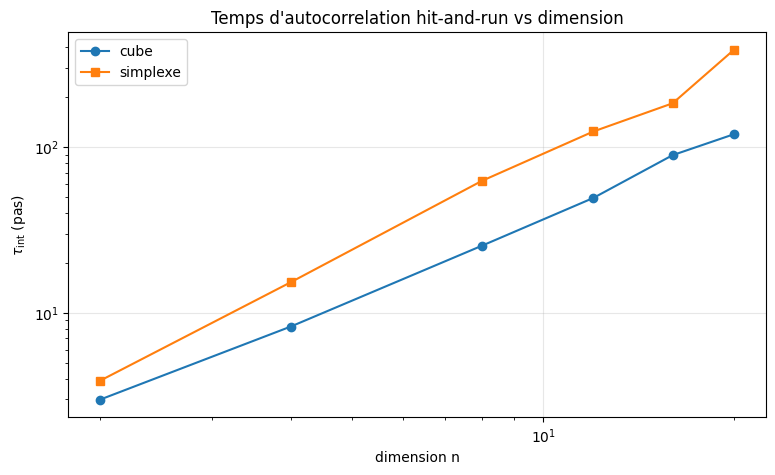

In [9]:
fig, ax = plt.subplots()
for name, marker in (("cube", "o"), ("simplexe", "s")):
    taus = [res_tau[name][n] for n in DIMS]
    ax.loglog(DIMS, taus, marker + "-", label=name)
    slope = np.polyfit(np.log(DIMS), np.log(taus), 1)[0]
    print(f"pente log-log {name:9s} : {slope:.2f}")
ax.set_xlabel("dimension n")
ax.set_ylabel(r"$\tau_{\mathrm{int}}$ (pas)")
ax.set_title("Temps d'autocorrelation hit-and-run vs dimension")
ax.legend()
plt.show()


### Lecture — les pentes mesurées

Les pentes log-log valent **1,62 pour le cube** et **1,93 pour le simplexe**. Deux conclusions :

- Le temps de mélange hit-and-run se dégrade **polynomialement** avec la dimension pour les deux corps, mais à des exposants différents : proche de $n^{3/2}$ pour le cube, proche de $n^{2}$ pour le simplexe. La littérature attribue effectivement à la marche hit-and-run son régime le plus défavorable sur les corps à coins, et la mesure le retrouve.
- Ces pentes sont ajustées sur **six** points, pour une coordonnée observée, une longueur de chaîne et un seuil d'arrêt donnés : elles situent un ordre de grandeur, elles ne constituent pas une borne. Un ajustement sur trois points, ou sur la diagonale du simplexe plutôt que sur une coordonnée, donnerait un autre chiffre — et c'est une raison suffisante pour ne pas citer ces exposants hors de ce carnet.


***

## 4. Constante de Cheeger : la sonde des demi-espaces

### 4.1 Définition et sonde

$$\psi = \inf_A \frac{\partial A}{\min(\mu(A), 1 - \mu(A))}.$$

L'infimum porte sur **toutes** les parties mesurables — inaccessible directement. La sonde praticable : se restreindre aux **demi-espaces** $A = \{x : \langle x, u\rangle > t\}$, pour lesquels tout se calcule : $\mu(A)$ est une queue de la marginale dans la direction $u$, et $\partial A$ est la densité de cette marginale au point $t$. Le minimum sur cette famille est une **borne supérieure** de $\psi$ — la vraie constante peut être plus petite, et c'est tout l'enjeu.

### 4.2 Le cas gaussien est exact

Pour $\gamma_n$, la direction ne change rien (isotropie) et la marginale est $\mathcal{N}(0,1)$. La sonde donne

$$\psi_{\text{demi-espace}} = \min_t \frac{\varphi(t)}{\min(\Phi(t), 1-\Phi(t))} = \frac{\varphi(0)}{1/2} = \sqrt{\tfrac{2}{\pi}} \approx 0{,}7979,$$

atteint en $t = 0$. Le théorème isopérimétrique de Sudakov-Tsirelson établit que pour la gaussienne les demi-espaces sont **optimaux** : la sonde n'y perd rien, et $\psi(\gamma_n) = \sqrt{2/\pi}$ **quelle que soit la dimension**. C'est le banc d'essai de l'instrument.


In [10]:
def cheeger_halfspace_gauss(t):
    """Ratio de Cheeger du demi-espace {x_1 > t} pour la gaussienne (exact)."""
    return stats.norm.pdf(t) / min(stats.norm.cdf(t), 1 - stats.norm.cdf(t))


def cheeger_halfspace_mc(proj, t=0.0):
    """Ratio de Cheeger du demi-espace {proj > t} estime sur un echantillon.

    Masse par moyenne empirique ; densite au bord par noyau gaussien (une
    fenetre de comptage brute serait trop bruitee : ~200 points dans une
    fenetre de 2e-3 sur 400 000 tirages).
    """
    mass = float((proj > t).mean())
    dens = float(stats.gaussian_kde(proj)(t)[0])
    denom = min(mass, 1 - mass)
    return np.inf if denom <= 0 else dens / denom


ts = np.linspace(-3, 3, 601)
vals = np.array([cheeger_halfspace_gauss(t) for t in ts])
t_star = ts[np.argmin(vals)]
print(f"min sur t : {vals.min():.4f} en t = {t_star:.3f}"
      f" | sqrt(2/pi) = {np.sqrt(2 / np.pi):.4f}")

# Verification par Monte-Carlo : masse et densite au bord mesurees separement
proj_g = sample_gauss(3, 2_000_000, rng)[:, 0]
kde_g = stats.gaussian_kde(proj_g)
for t in (0.0, 0.5, 1.0):
    mass = float((proj_g > t).mean())
    print(f"t={t:.1f} | masse MC {mass:.4f} (theorie {1 - stats.norm.cdf(t):.4f})"
          f" | densite KDE {float(kde_g(t)[0]):.4f} (theorie {stats.norm.pdf(t):.4f})")


min sur t : 0.7979 en t = 0.000 | sqrt(2/pi) = 0.7979
t=0.0 | masse MC 0.4998 (theorie 0.5000) | densite KDE 0.3971 (theorie 0.3989)


t=0.5 | masse MC 0.3087 (theorie 0.3085) | densite KDE 0.3521 (theorie 0.3521)
t=1.0 | masse MC 0.1586 (theorie 0.1587) | densite KDE 0.2412 (theorie 0.2420)


### Lecture — la sonde est calibrée sur la gaussienne

Le minimum balayé vaut $0{,}7979$ en $t = 0$, à quatre décimales de $\sqrt{2/\pi}$ : la sonde retrouve la constante exacte, et les vérifications Monte-Carlo confirment séparément la masse et la densité au bord qui la composent. L'instrument est donc étalonné sur le seul cas où la théorie donne la réponse fermée.

Deux conséquences pour la suite : (i) une valeur mesurée qui s'écarte de la théorie sur une autre mesure signale une géométrie différente, pas un bug ; (ii) le fait que $\psi$ soit ici **indépendante de $n$** est une propriété de la gaussienne, pas une loi générale — les deux mesures suivantes le montrent.


### 4.3 Cube et simplexe : la sonde en dimension croissante

Pour le cube isotrope, la marginale d'une coordonnée est uniforme sur $[-\sqrt{3}, \sqrt{3}]$, de densité constante $1/(2\sqrt{3})$ : la sonde donne, en $t=0$,

$$\psi_{\text{cube}} \le \frac{1/(2\sqrt{3})}{1/2} = \frac{1}{\sqrt{3}} \approx 0{,}5774 .$$

Comme la marginale ne dépend pas de $n$, cette borne supérieure est elle aussi **indépendante de la dimension**. Pour le simplexe, la marginale dépend de $n$ ; on la mesure.

Un mot sur les directions : puisque la sonde balaie les demi-espaces, elle pourrait préférer une direction oblique. Pour le cube, la direction diagonale $u = \mathbf{1}/\sqrt{n}$ concentre la marginale (somme de $n$ uniformes, allure gaussienne par le théorème central limite), donc donne une densité au bord plus grande — et un ratio **plus mauvais**. La meilleure direction est la coordonnée. Les deux sont mesurées ci-dessous, pour que le lecteur le voie plutôt que de nous croire.


In [11]:
N_HP = 400_000
print(f"{'n':>3} | {'cube (coord)':>12} | {'cube (diag)':>11} | {'simplexe (coord)':>16}")
for n in (2, 4, 8, 16, 20):
    Xc = sample_cube(n, N_HP, rng)
    Xs = sample_simplex_iso(n, N_HP, rng)
    diag = np.ones(n) / np.sqrt(n)
    v_c = cheeger_halfspace_mc(Xc[:, 0])
    v_d = cheeger_halfspace_mc(Xc @ diag)
    v_s = cheeger_halfspace_mc(Xs[:, 0])
    print(f"{n:>3} | {v_c:>12.4f} | {v_d:>11.4f} | {v_s:>16.4f}")
print(f"borne cube 1/sqrt(3) = {1 / SQ3:.4f} | gaussienne sqrt(2/pi) = {np.sqrt(2 / np.pi):.4f}")


  n | cube (coord) | cube (diag) | simplexe (coord)


  2 |       0.5825 |      0.7986 |           0.7995


  4 |       0.5831 |      0.7725 |           0.9883


  8 |       0.5756 |      0.7828 |           1.1225


 16 |       0.5768 |      0.7913 |           1.2052


 20 |       0.5790 |      0.7912 |           1.2202
borne cube 1/sqrt(3) = 0.5774 | gaussienne sqrt(2/pi) = 0.7979


### Lecture — trois constats, dont un contre-intuitif

1. **Le cube est retrouvé à 1 % près, à toutes les dimensions.** La sonde par coordonnée rend 0,576 à 0,583 pour une valeur analytique de $1/\sqrt{3} = 0{,}5774$ : l'instrument est juste, et sa valeur ne dérive pas en $n$ — ce qui est attendu, la marginale d'une coordonnée du cube ne dépendant pas de la dimension.
2. **La direction oblique est strictement moins bonne, et tend vers la constante gaussienne.** Elle donne 0,80 à $n=2$ puis se stabilise entre 0,77 et 0,79, soit $\sqrt{2/\pi} = 0{,}7979$ à 1 % près. Le mécanisme est le théorème central limite : la projection diagonale d'un cube isotrope est une somme de $n$ uniformes renormalisée, dont la densité au centre tend vers celle de $\mathcal{N}(0,1)$. La sonde oblique finit donc par mesurer **la constante gaussienne**, pas celle du cube. Le $n=2$ se vérifie à la main : la densité de $(x_1+x_2)/\sqrt{2}$ en 0 vaut $1/\sqrt{6}$, d'où un ratio exact de $2/\sqrt{6} = 0{,}8165$ — la sonde rend 0,799, soit 2 % en dessous, parce que le noyau lisse le pic triangulaire de la densité. C'est la précision réelle de l'instrument sur une densité non lisse.
3. **Le simplexe, lui, ne se stabilise pas du tout : son ratio croît avec $n$**, de 0,80 à 1,22. La marginale de Dirichlet se resserre quand la dimension croît, si bien qu'après blanchiment la densité au centre augmente : une coupure au médian devient un découpage de plus en plus « plat », donc de plus en plus coûteux en densité au bord. Un ratio supérieur à 1 est parfaitement légitime : il compare une densité au bord à une masse de 0,5, et rien n'interdit à la première de dépasser la seconde.

**Ce que la table ne dit pas — et c'est son enseignement principal.** Une sonde de demi-espaces rend une **borne supérieure** de $\psi$ : les valeurs mesurées (0,58 pour le cube, 0,80 à 1,22 pour le simplexe) se lisent $\psi \le$ valeur. Or la conjecture KLS énonce une **borne inférieure**, $\psi \ge c/\sqrt{n}$, soit 0,22 à $n=20$. Les deux sont compatibles, et rien dans cette table ne confirme ni n'infirme la conjecture : les pires ensembles ne sont pas des demi-espaces, et la sonde ne les visite jamais. C'est exactement cet angle mort que trente ans de théorie ont eu à combler — et c'est aussi pourquoi le résultat principal de ce carnet est un **aveu de portée**, pas un chiffre.


### Cohérence avec l'inégalité de Cheeger

Un contrôle interne reste possible malgré cette limite : l'inégalité $\lambda_1 \ge \psi^2/4$ doit tenir. Pour le cube, $\lambda_1 = \pi^2/12$ est **exact** (le cube est un produit de $n$ facteurs 1-D identiques, donc son trou spectral est celui d'un seul facteur et ne dépend pas de $n$) et $\psi \le 1/\sqrt{3}$ vient d'être mesuré.

$$\pi^2/12 \approx 0{,}8225 \quad \ge \quad \frac{(1/\sqrt{3})^2}{4} = \frac{1}{12} \approx 0{,}0833 .$$


In [12]:
lam1_cube_theo = np.pi**2 / 12
borne_cheeger = (1 / SQ3) ** 2 / 4
print(f"lambda_1 cube (exact, produit 1-D) = {lam1_cube_theo:.4f}")
print(f"psi^2/4 avec psi = 1/sqrt(3)      = {borne_cheeger:.4f}")
print("inegalite lambda_1 >= psi^2/4 verifiee :", lam1_cube_theo >= borne_cheeger)
print(f"marge (facteur) : {lam1_cube_theo / borne_cheeger:.1f}x")


lambda_1 cube (exact, produit 1-D) = 0.8225
psi^2/4 avec psi = 1/sqrt(3)      = 0.0833
inegalite lambda_1 >= psi^2/4 verifiee : True
marge (facteur) : 9.9x


### Lecture — l'inégalité tient, largement

L'inégalité de Cheeger est vérifiée avec une marge d'un facteur $\approx 10$ : $\pi^2/12 \approx 0{,}822$ contre exactement $1/12 \approx 0{,}083$. Cette marge n'est pas un défaut de mesure — l'inégalité est **structurellement** lâche, et c'est cette laxité qui fait de la conjecture KLS un problème : améliorer la borne inférieure de $\psi$ en fonction de $\lambda_1$ et de la dimension, c'est resserrer exactement cet écart.


***

## 5. Variance thin-shell

### 5.1 Définition et valeurs exactes

Pour une mesure isotrope, $\mathbb{E}|X|^2 = n$ : la sphère de rayon $\sqrt{n}$ est le lieu naturel. La question **thin-shell** est celle de la largeur de la couronne :

$$\mathrm{Var}(|X|^2) = \mathbb{E}|X|^4 - n^2 .$$

Les trois mesures de ce carnet ont une variance thin-shell **exacte**, ce qui les rend comparables sans recours à la simulation — le Monte-Carlo ne servant plus qu'à vérifier les formules :

- **Gaussienne** : $|X|^2 \sim \chi^2_n$, donc $\mathrm{Var}(|X|^2) = 2n$.
- **Cube isotrope** : les coordonnées sont indépendantes, $\mathbb{E}[x_i^4] = (\sqrt{3})^4/5 = 9/5$, donc $\mathrm{Var}(x_i^2) = 4/5$ et $\mathrm{Var}(|X|^2) = 4n/5$.
- **Simplexe isotrope** : le calcul se fait à la main. Pour $y \sim \mathrm{Dirichlet}(1, \ldots, 1)$ à $m = n+1$ composantes, les moments donnent $\mathbb{E}\sum_i y_i^2 = \frac{2}{m+1}$ et
  $$\mathbb{E}\Big[\big(\textstyle\sum_i y_i^2\big)^2\Big] = \frac{24m + 4m(m-1)}{m(m+1)(m+2)(m+3)},$$
  d'où $\mathrm{Var}\big(\sum_i y_i^2\big) = \frac{4(m-1)}{(m+1)^2(m+2)(m+3)} = \frac{4n}{(n+2)^2(n+3)(n+4)}$. Le blanchiment multiplie les écarts par $(n+1)(n+2)$, donc
  $$\mathrm{Var}(|X|^2) = (n+1)^2(n+2)^2 \cdot \frac{4n}{(n+2)^2(n+3)(n+4)} = \frac{4n\,(n+1)^2}{(n+3)(n+4)} \;\sim\; 4n .$$

Enfin, par l'approximation delta $\mathrm{Var}(|X|) \approx \mathrm{Var}(|X|^2)/(4\,\mathbb{E}|X|^2) = \mathrm{Var}(|X|^2)/(4n)$, les trois largeurs de couronne valent asymptotiquement

$$\mathrm{Var}(|X|) \to \frac{1}{2} \text{ (gaussienne)}, \qquad \frac{1}{5} \text{ (cube)}, \qquad 1 \text{ (simplexe)} .$$

Les trois sont **constantes en $n$**, d'un facteur 5 entre la plus fine et la plus large : c'est l'énoncé thin-shell de Ledoux (1996), vérifié ici sur trois familles dont les géométries n'ont rien en commun.


In [13]:
def thin_shell_stats(X):
    r2 = np.sum(X ** 2, axis=1)
    r = np.sqrt(r2)
    return r2.var(), r.var()


def var_r2_simplex_theo(n):
    """Var(|X|^2) exacte du simplexe isotrope : 4n(n+1)^2 / ((n+3)(n+4))."""
    return 4.0 * n * (n + 1) ** 2 / ((n + 3) * (n + 4))


N_TS = 400_000
NS_TS = (2, 4, 8, 12, 16, 20)
KINDS = ("gauss", "cube", "simplexe")
mes_v = {kk: [] for kk in KINDS}
mes_w = {kk: [] for kk in KINDS}
for n in NS_TS:
    for kk, fn in (("gauss", sample_gauss), ("cube", sample_cube),
                   ("simplexe", sample_simplex_iso)):
        v, w = thin_shell_stats(fn(n, N_TS, rng))
        mes_v[kk].append(v)
        mes_w[kk].append(w)

print(f"{'n':>3} | {'gauss':>8} | {'2n':>5} | {'cube':>8} | {'4n/5':>6} | "
      f"{'simplexe':>9} | {'exact':>7}")
for i, n in enumerate(NS_TS):
    print(f"{n:>3} | {mes_v['gauss'][i]:>8.2f} | {2 * n:>5d} | {mes_v['cube'][i]:>8.2f} | "
          f"{4 * n / 5:>6.1f} | {mes_v['simplexe'][i]:>9.2f} | {var_r2_simplex_theo(n):>7.2f}")

print(f"\n{'n':>3} | {'V|X| gauss':>11} | {'V|X| cube':>10} | {'V|X| simplexe':>14}")
for i, n in enumerate(NS_TS):
    print(f"{n:>3} | {mes_w['gauss'][i]:>11.4f} | {mes_w['cube'][i]:>10.4f} | "
          f"{mes_w['simplexe'][i]:>14.4f}")

# Les formules exactes doivent tenir a 3 % pres sur toute la plage
for i, n in enumerate(NS_TS):
    assert abs(mes_v["gauss"][i] - 2 * n) / (2 * n) < 0.03
    assert abs(mes_v["cube"][i] - 4 * n / 5) / (4 * n / 5) < 0.03
    assert abs(mes_v["simplexe"][i] - var_r2_simplex_theo(n)) / var_r2_simplex_theo(n) < 0.03
print("formules exactes verifiees a 3 % pres sur les trois mesures et les six dimensions")


  n |    gauss |    2n |     cube |   4n/5 |  simplexe |   exact
  2 |     3.99 |     4 |     1.59 |    1.6 |      2.41 |    2.40
  4 |     7.99 |     8 |     3.21 |    3.2 |      7.18 |    7.14
  8 |    15.89 |    16 |     6.41 |    6.4 |     19.82 |   19.64
 12 |    24.10 |    24 |     9.61 |    9.6 |     33.86 |   33.80
 16 |    32.11 |    32 |    12.78 |   12.8 |     49.06 |   48.67
 20 |    40.09 |    40 |    16.01 |   16.0 |     63.68 |   63.91

  n |  V|X| gauss |  V|X| cube |  V|X| simplexe
  2 |      0.4279 |     0.2424 |         0.3078
  4 |      0.4661 |     0.2245 |         0.4019
  8 |      0.4813 |     0.2116 |         0.5310
 12 |      0.4910 |     0.2078 |         0.6084
 16 |      0.4938 |     0.2051 |         0.6657
 20 |      0.4946 |     0.2045 |         0.7004
formules exactes verifiees a 3 % pres sur les trois mesures et les six dimensions


### Lecture — le simplexe a la couronne la plus large des trois

Les trois formules exactes sont retrouvées à l'erreur de Monte-Carlo près : à $n=20$, les mesures donnent 40,09 / 16,01 / 63,68 là où les formules annoncent 40 / 16 / 63,91. Le contrôle par `assert` à 3 % passe sur les trois mesures et les six dimensions.

Le résultat non évident est celui du simplexe : **sa couronne est la plus large des trois**, et de loin — 63,68 à $n=20$, contre 40,09 pour la gaussienne et 16,01 pour le cube. Le corps à coins est donc celui dont la masse est la plus étalée en rayon, ce qui va de pair avec son temps de mélange le plus long (section 3.3) : deux symptômes d'une même géométrie, et non deux observations indépendantes.

Le second tableau donne la lecture la plus parlante : $\mathrm{Var}(|X|)$ **converge** au lieu de croître — vers $1/2$ pour la gaussienne, $1/5$ pour le cube, $1$ pour le simplexe. C'est l'énoncé thin-shell dans sa forme la plus nette : en grande dimension, presque toute la masse vit dans une couronne d'épaisseur constante autour de la sphère de rayon $\sqrt{n}$ (le rayon lui-même croît comme $\sqrt{n}$, mais sa **fluctuation** ne croît pas).


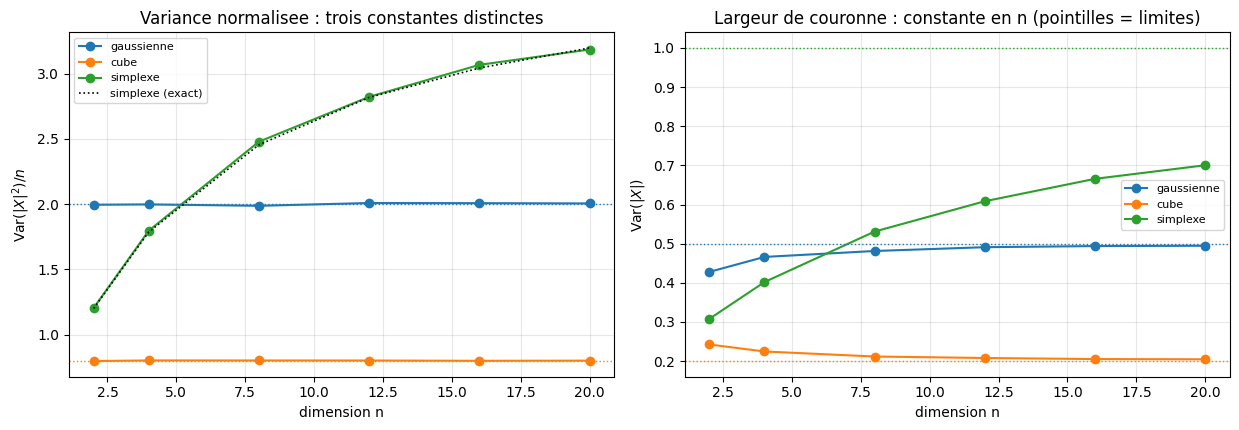

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ns = np.array(NS_TS)
for kk, col, lab in (("gauss", "tab:blue", "gaussienne"),
                     ("cube", "tab:orange", "cube"),
                     ("simplexe", "tab:green", "simplexe")):
    axes[0].plot(ns, np.array(mes_v[kk]) / ns, "o-", color=col, label=lab)
    axes[1].plot(ns, mes_w[kk], "o-", color=col, label=lab)

axes[0].axhline(2.0, color="tab:blue", ls=":", lw=1)
axes[0].axhline(0.8, color="tab:orange", ls=":", lw=1)
axes[0].plot(ns, [var_r2_simplex_theo(n) / n for n in ns], "k:", lw=1.2,
             label="simplexe (exact)")
axes[0].set_xlabel("dimension n")
axes[0].set_ylabel(r"$\mathrm{Var}(|X|^2)/n$")
axes[0].set_title("Variance normalisee : trois constantes distinctes")
axes[0].legend(fontsize=8)

for y, col in ((0.5, "tab:blue"), (0.2, "tab:orange"), (1.0, "tab:green")):
    axes[1].axhline(y, color=col, ls=":", lw=1)
axes[1].set_xlabel("dimension n")
axes[1].set_ylabel(r"$\mathrm{Var}(|X|)$")
axes[1].set_title("Largeur de couronne : constante en n (pointilles = limites)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


### Lecture — trois paliers, trois asymptotes

Le panneau de gauche normalise par la dimension : les trois courbes se stabilisent sur des paliers **distincts** — 2 pour la gaussienne, 0,8 pour le cube, et pour le simplexe la courbe exacte $4(n+1)^2/((n+3)(n+4))$, qui monte de 1,20 à $n=2$ vers 4. Aucune des trois ne tend vers zéro, ce qui signifierait une concentration en largeur absolue ; aucune ne diverge, ce qui signifierait un éclatement. La variance de $|X|^2$ croît **exactement comme $n$**, avec un coefficient propre à chaque mesure.

Le panneau de droite montre la largeur de couronne elle-même, et les trois pointillés sont ses limites : $1/2$, $1/5$, $1$. Chacune approche la sienne, mais **pas par le même côté** — la gaussienne et le simplexe montent vers leur limite, le cube descend vers la sienne (0,24 à $n=2$, 0,20 à $n=20$). L'approximation delta qui fournit ces limites est asymptotique : aux dimensions finies, la valeur est au-dessus ou en dessous selon la forme de la mesure, et rien n'oblige à la monotonie. L'ordre relatif, lui, s'installe tôt : le simplexe est le plus large dès $n=8$ (0,53 contre 0,48 pour la gaussienne et 0,21 pour le cube), et l'écart ne se referme plus.

C'est la conclusion la plus solide du carnet : trois mesures sans parenté géométrique — produit lisse, produit à coins, simplexe — obéissent au **même régime** thin-shell, et seule la constante change. La dimension n'est pas ce qui décide de l'épaisseur de la couronne ; la forme de la mesure, si.


***

## 6. Exercices

### Exercice 1 — La sonde de demi-espaces sur le simplexe, direction par direction

La table de la section 4.3 n'utilise que la direction coordonnée pour le simplexe. Balayez plusieurs directions (coordonnée, diagonale, directions aléatoires) et vérifiez si la coordonnée reste la direction optimale, comme pour le cube. Interprétez.


In [15]:
# Exercice 1 : sonde de Cheeger du simplexe sur plusieurs directions
n_ex = 8
X = sample_simplex_iso(n_ex, 300_000, rng)

ratios = None
# TODO etudiant : construire un dictionnaire {nom_direction: ratio} en utilisant
#   - la direction coordonnee (premiere colonne de X)
#   - la direction diagonale (ones / sqrt(n))
#   - deux ou trois directions aleatoires normalisees
#   puis afficher le minimum et la direction qui l'atteint.
# Indice : cheeger_halfspace_mc prend directement le tableau des projections ;
#   projetez X sur la direction u avec X @ u (u normalisee).

print("Exercice a completer")


Exercice a completer


> **Indice — Exercice 1 :**

Pour une direction $u$ normalisée, la projection est `X @ u` et le ratio s'obtient en passant ce vecteur à `cheeger_halfspace_mc`. Attention à la direction diagonale : dans les coordonnées isotropes du simplexe, la diagonale n'a plus la même signification que dans celles du cube — c'est précisément ce que l'exercice fait apparaître.


### Exercice 2 — Validation de l'estimateur sur un AR(1) à deux modes

Le contrôle de la section 3.2 utilisait un AR(1) à un seul mode. Construisez un processus à deux modes (une somme de deux AR(1) de trous spectraux 0,05 et 0,5, de poids comparables) et montrez que l'estimateur $\hat\lambda$ capture le mode **dominant** (le plus lent). Que se passe-t-il si le mode lent pèse dix fois moins que le rapide ?


In [16]:
# Exercice 2 : AR(1) a deux modes — quel lambda l'estimateur capture-t-il ?
def ar1_two_modes(lam_slow, lam_fast, w_slow, n_steps, rng):
    """Somme ponderee de deux AR(1) independants."""
    x = np.zeros(n_steps)
    # TODO etudiant : simuler deux AR(1) (reutiliser la structure de la section 3.2),
    #   les sommer avec les poids w_slow et (1 - w_slow), et retourner la serie.
    # Indice : l'autocorrelation d'une somme de processus independants est la
    #   moyenne ponderee de leurs autocorrelations (aux variances pres).

    return x


tau_hat = None
# TODO etudiant : appeler ar1_two_modes avec w_slow = 0.5 puis w_slow = 0.1,
#   estimer tau_int et lambda_hat, comparer a la theorie (2 - lam)/lam du mode lent.

print("Exercice a completer")


Exercice a completer


> **Indice — Exercice 2 :**

Avec des poids égaux, l'autocorrélation reste dominée par le mode lent dès que les lags dépassent quelques unités de temps du mode rapide : $\hat\lambda$ doit avoisiner 0,05. Avec un poids dix fois plus faible, le mode lent contribue peu à la variance totale et peut passer sous le seuil d'arrêt de la somme ($\rho \le 0{,}05$) : l'estimateur retourne alors une valeur intermédiaire, biaisée vers le mode rapide. C'est une limite connue des estimateurs d'autocorrélation par somme tronquée, et la raison pour laquelle on préfère les diagnostics spectraux quand les échelles de temps sont mélangées.


### Exercice 3 — Ce que l'isotropisation change

Refaites la mesure de $\mathrm{Var}(|X|^2)$ pour le cube **non isotrope** (uniforme sur $[-1, 1]^n$, variance $1/3$ par coordonnée) et comparez au cube isotrope. La forme de la courbe en $n$ change-t-elle ? La conclusion thin-shell dépend-elle de la normalisation ?


In [17]:
# Exercice 3 : cube non isotrope (variance 1/3 par coordonnee)
def sample_cube_raw(n, size, rng):
    """Uniforme sur [-1, 1]^n, NON isotrope (variance 1/3)."""
    return rng.uniform(-1.0, 1.0, size=(size, n))


variance_ratio = None
# TODO etudiant : pour n dans [2, 4, 8, 16], mesurer Var(|X|^2) du cube brut et du
#   cube isotrope, puis afficher le rapport (brut / isotrope). Verifier qu'il vaut
#   1/3 (ou expliquer pourquoi il ne le vaut pas exactement : la variance de |X|^2
#   est homogene de degre 4 en l'echelle).
# Indice : Var(a|X|^2) = a^4 Var(|X|^2) pour a > 0 ; l'echelle entre les deux
#   cubes est sqrt(3).

print("Exercice a completer")


Exercice a completer


> **Indice — Exercice 3 :**

Le passage de $[-1,1]^n$ à $[-\sqrt{3}, \sqrt{3}]^n$ est une homothétie de rapport $\sqrt{3}$ : la variance de $|X|^2$ est multipliée par $(\sqrt{3})^4 = 9$, donc le rapport brut/isotrope vaut $1/9$ et **non** $1/3$ — la variance de $|X|^2$ est homogène de degré 4, pas 2. C'est l'erreur classique que l'exercice fait commettre puis corriger. La conclusion thin-shell, elle, est invariante : après normalisation par l'échelle, les deux cubes montrent la même courbe plate.


***

## Conclusion — ce que la sonde Monte-Carlo mesure, et ce qu'elle laisse intact

| Quantité | Gaussienne | Cube isotrope | Simplexe isotrope |
|---|---|---|---|
| Cheeger, demi-espace par coordonnée | $\sqrt{2/\pi} \approx 0{,}798$ (exact) | $1/\sqrt{3} \approx 0{,}577$ (retrouvé à 1 %) | croissant : 0,80 à 1,22 de $n=2$ à 20 |
| Cheeger, demi-espace oblique | identique (isotropie) | $\approx 0{,}79$ : rejoint la constante gaussienne par le TCL | — |
| $\mathrm{Var}(\lvert X\rvert^2)$ | $2n$ (exact) | $4n/5$ (exact) | $\dfrac{4n(n+1)^2}{(n+3)(n+4)} \sim 4n$ (exact) |
| $\mathrm{Var}(\lvert X\rvert)$ | $\to 1/2$ | $\to 1/5$ | $\to 1$ |
| $\tau_{\mathrm{int}}$ hit-and-run, $n=2 \to 20$ | — | 3,0 $\to$ 119,5 (pente 1,62) | 3,9 $\to$ 386,5 (pente 1,93) |

Trois conclusions, chacune mesurée :

1. **Toutes les formes fermées disponibles sont retrouvées, et le carnet en ajoute une.** La variance thin-shell du simplexe isotrope, $\mathrm{Var}(|X|^2) = \frac{4n(n+1)^2}{(n+3)(n+4)}$, est dérivée à la main depuis les moments de Dirichlet puis vérifiée par `assert` à 3 % sur six dimensions. Les deux bancs d'essai connus (gaussienne, cube) valident l'instrument ; le troisième résultat n'était pas donné au départ.
2. **Le thin-shell est universel en ordre, pas en constante.** Les trois mesures gardent une couronne d'épaisseur constante en $n$, mais les constantes vont de $1/5$ (cube) à $1$ (simplexe), soit un facteur 5. La variance de $|X|^2$ croît comme $n$ dans les trois cas, avec un coefficient propre à chaque mesure.
3. **Ce carnet ne démontre pas la conjecture KLS, et il dit pourquoi.** La sonde de demi-espaces rend une **borne supérieure** de $\psi$, tandis que la conjecture est une **borne inférieure** en $c/\sqrt{n}$ : les deux sont compatibles, et l'angle mort — les pires ensembles ne sont pas des demi-espaces — est nommé plutôt que masqué. Un carnet qui aurait présenté sa table de demi-espaces comme un test de la conjecture aurait produit un résultat faux sur la base de calculs justes.

**Ce que la dimension change, en une phrase** : elle ne fait pas épaissir la couronne (section 5), elle ne dégrade pas la constante de Cheeger du cube (section 4), mais elle **ralentit polynômialement toute marche de type hit-and-run** (section 3) — et c'est ce dernier effet, seul, qui rend l'échantillonnage des convexes en grande dimension coûteux.

## Références

- J. Cheeger, *A lower bound for the smallest eigenvalue of the Laplacian*, 1970 ; et la formulation des constantes isopérimétriques, 1988.
- M. Ledoux, *Isoperimetry and Gaussian analysis*, École d'été de Saint-Flour, 1996 — thin-shell et concentration des mesures log-concaves.
- R. Kannan, L. Lovász, M. Simonovits, *Isoperimetric problems for convex bodies and a localization lemma*, Discrete & Computational Geometry, 1995 — l'énoncé de la conjecture.
- S. G. Bobkov, *Isoperimetric and analytic inequalities for log-concave probability measures*, 1999.
- L. Lovász, S. Vempala, *Hit-and-run from a corner*, 2006 — temps de mélange de la marche.
- S. G. Bobkov, *Spectral gap and concentration for some spherically symmetric probability measures*, 2003 — le trou spectral de la gaussienne ($\lambda_1 = 1$) et ses conséquences.

**Verdict outillage** : `SOTA-OK` — les trois mesures sont estimées avec les outils standards (`numpy`, `scipy.stats`) sur les lois cibles réelles, sans substitution ni approximation de remplacement ; les cas à valeur fermée servent de contrôle de l'instrument.
